In [1]:
import sys
import os
from pathlib import Path
sys.path.append(os.path.abspath("../.."))
from quantile_forest import RandomForestQuantileRegressor
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from tinyconformal.regressor import ConformalizedQuantileRegressor
import numpy as np

In [2]:
EXAMPLES_DIR = Path.cwd().parent
if str(EXAMPLES_DIR) not in sys.path:
    sys.path.insert(0, str(EXAMPLES_DIR))
from utils.plot_utils import plot_prediction_intervals

In [3]:
data = fetch_california_housing(as_frame=True)
X, y = data.data, data.target


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_calib, y_train, y_calib = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

In [57]:
coverage = 0.90
alpha = 1 - coverage
quantiles = [alpha/2, 1 - alpha/2]

In [19]:
rf = RandomForestQuantileRegressor(random_state=42, default_quantiles=quantiles, n_jobs=-1, oob_score=True, max_depth=int(np.ceil(np.log2(len(X_train)) - 1)))
rf.fit(X_train, y_train)

,n_estimators,100
,default_quantiles,"[0.04999999999999999, 0.95]"
,criterion,'squared_error'
,max_depth,13
,min_samples_split,2
,min_samples_leaf,1
,max_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0


In [20]:
rf.predict(X_test)

array([[0.4169 , 0.612  ],
       [0.521  , 1.59025],
       [3.1    , 5.00001],
       ...,
       [2.458  , 5.00001],
       [0.56165, 0.856  ],
       [1.15305, 2.2229 ]], shape=(4128, 2))

In [21]:
reg = ConformalizedQuantileRegressor(
    rf,
    alpha=alpha,
)
reg.fit(X_train, y_train, oob=True)

,learner,RandomForestQ...ndom_state=42)
,alpha,0.09999999999999998
,n_estimators,100
,default_quantiles,"[0.04999999999999999, 0.95]"
,criterion,'squared_error'
,max_depth,13
,min_samples_split,2
,min_samples_leaf,1
,max_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0


In [22]:
reg

,learner,RandomForestQ...ndom_state=42)
,alpha,0.09999999999999998
,n_estimators,100
,default_quantiles,"[0.04999999999999999, 0.95]"
,criterion,'squared_error'
,max_depth,13
,min_samples_split,2
,min_samples_leaf,1
,max_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0


In [37]:
y_pred_intervals = reg.predict_interval(X_test, alpha=0.2)
y_pred = reg.predict(X_test, alpha=0.2)

In [39]:
reg.evaluate(X_test, y_test, alpha=0.2)

{'total': 4128,
 'alpha': 0.2,
 'beta': None,
 'coverage_rate': np.float64(0.727),
 'interval_width_mean': np.float64(1.036),
 'mwis': np.float64(1.624),
 'mae': np.float64(0.33),
 'mbe': np.float64(-0.039),
 'mse': np.float64(0.273)}

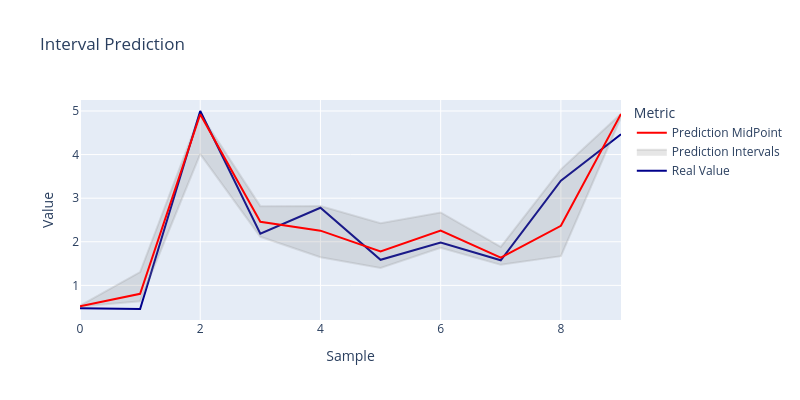

In [40]:
plot_prediction_intervals(y_pred_intervals[:10], y_pred[:10], y_test[:10], fig_type="png")

In [43]:
# Copyright (c) 2024-2026 Lucas Leão
# TinyConformal - A small toolbox for conformal prediction
# Licensed under the MIT License

import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin, clone


class MultiQuantileRegressor(BaseEstimator, RegressorMixin):
    """
    A multi-quantile meta-estimator wrapper for mono-quantile regressors.

    Wraps any single-quantile regressor (e.g., LightGBM, XGBoost, CatBoost,
    HistGradientBoostingRegressor) and manages multiple quantile models internally.

    Parameters
    ----------
    base_estimator : BaseEstimator
        The base scikit-learn compatible estimator instance to clone.
    quantiles : tuple of float, default=(0.025, 0.5, 0.975)
        The target quantiles to fit during training.
    """

    def __init__(self, base_estimator: BaseEstimator, quantiles=(0.025, 0.5, 0.975)):
        self.base_estimator = base_estimator
        self.quantiles = tuple(quantiles)
        self.models_ = {}

    def _set_quantile_param(self, model: BaseEstimator, q: float) -> BaseEstimator:
        """
        Attempts to inject the target quantile parameter into the cloned model
        handling LightGBM, XGBoost, CatBoost, and scikit-learn conventions.
        """
        try:
            return model.set_params(alpha=q)
        except (ValueError, TypeError, KeyError):
            pass

        try:
            return model.set_params(quantile=q)
        except (ValueError, TypeError, KeyError):
            pass

        try:
            return model.set_params(loss_function=f"Quantile:alpha={q}")
        except (ValueError, TypeError, KeyError):
            pass

        raise AttributeError(
            f"Unable to set target quantile '{q}' on base estimator "
            f"'{model.__class__.__name__}'. Verify that the estimator supports quantile regression."
        )

    def fit(self, X, y):
        """
        Fits an independent clone of the base estimator for each quantile in `self.quantiles`.
        """
        self.models_ = {}
        for q in self.quantiles:
            model = clone(self.base_estimator)
            model = self._set_quantile_param(model, q)
            model.fit(X, y)
            self.models_[q] = model

        return self

    def predict(self, X, quantiles=None):
        """
        Generates predictions for all or a subset of trained quantiles.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Feature matrix.
        quantiles : list or tuple of float or None, default=None
            Subset of quantiles to evaluate. If None, predicts on all fitted quantiles.

        Returns
        -------
        y_pred : ndarray of shape (n_samples, len(quantiles))
            Stacked quantile predictions.
        """
        if not self.models_:
            raise ValueError("This MultiQuantileRegressor instance is not fitted yet.")

        if quantiles is None:
            quantiles = self.quantiles

        preds = []
        for q in quantiles:
            if q in self.models_:
                preds.append(self.models_[q].predict(X))
            else:
                raise ValueError(
                    f"Quantile {q} was not fitted. Available quantiles: {list(self.models_.keys())}"
                )

        return np.column_stack(preds)

In [44]:
from sklearn.ensemble import HistGradientBoostingRegressor

In [ ]:
mq_model = MultiQuantileRegressor(
        base_estimator=HistGradientBoostingRegressor(loss="quantile", random_state=42),
        quantiles=(0.1, 0.50, 0.90),
    )
mq_model.fit(X_train, y_train)
cqr = ConformalizedQuantileRegressor(learner=mq_model, alpha=0.2)
cqr.fit(X_calib, y_calib)

In [59]:
cqr.predict_interval(X_test)

array([[0.35432713, 1.55008457],
       [0.52303983, 2.45272456],
       [1.14201139, 5.25598672],
       ...,
       [2.27296538, 5.06638354],
       [0.56087723, 2.56463446],
       [1.28299388, 2.55230525]], shape=(4128, 2))

In [61]:
cqr.evaluate(X_test, y_test)

{'total': 4128,
 'alpha': 0.05,
 'beta': None,
 'coverage_rate': np.float64(0.951),
 'interval_width_mean': np.float64(2.058),
 'mwis': np.float64(2.648),
 'mae': np.float64(0.323),
 'mbe': np.float64(-0.07),
 'mse': np.float64(0.262)}

In [62]:
bounds = cqr.predict_interval(X_test)
y_pred = cqr.predict(X_test)

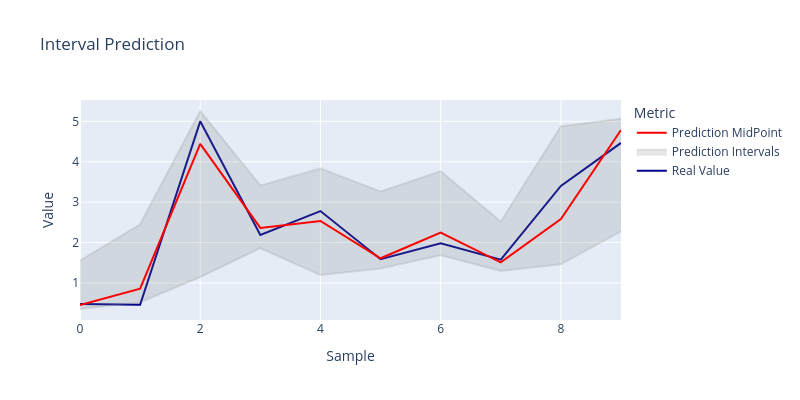

In [63]:
plot_prediction_intervals(bounds[:10], y_pred[:10], y_test[:10], fig_type="png")